In [1]:
!pip install -e .

Obtaining file:///Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/scptm
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scptm (pyproject.toml) ... done
  Created wheel for scptm: filename=scptm-0.2.0-0.editable-py3-none-any.whl size=8854 sha256=3552bdcb1388393c3fa40c777e2fac82a7838787cceb390c08e41b302f64986d
  Stored in directory: /private/var/folders/_8/fy4pl38d2tv85vx03yk7wlx00000gn/T/pip-ephem-wheel-cache-253s38un/wheels/95/76/bb/5a7ea3a4a49f2cd771782040a829275073a503c1102f0d8fca
Successfully built scptm
  Attempting uninstall: scptm
    Found existing installation: scptm 0.2.0
    Uninstalling scptm-0.2.0:
      Successfully uninstalled scptm-0.2.0

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
from scptm import SCPTM, SCPTMConfig
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from scptm.evaluation import compute_npmi_coherence, compute_topic_diversity
from scptm.graph import prepare_corpus
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

NOVELS_PATH = "/Users/alemeneghini/Dropbox/stat/CPTM/10_english_novels"   # ← aggiusta questo
CACHE       = "novels_cache.pkl"
K           = 20    # romanzi → più temi, prova 10-20

# ── Carica corpus una volta sola ─────────────────────────────────────────────
# apply_chunking=True: siccome lavoriamo con dati di romanzi sono lunghi, vengono spezzati in segmenti
# da ~800 caratteri (singoli paragrafi/scene) — unità più appropriate dei
# documenti interi per il topic modeling
docs = prepare_corpus(
    NOVELS_PATH,
    source_type   = "folder",
    apply_chunking = True,
    max_chunk_chars = 800,
)
print(f"Corpus: {len(docs)} segmenti da {len(set(docs))} file")

BASE = dict(
    num_topics      = K,
    lang            = "eng",
    epochs          = 50,
    apply_chunking  = False,   # già chunked sopra
    min_df          = 10,      # con ~3000+ segmenti, alza un po' il floor
    max_features    = 20_000,  # vocabolario letterario più ampio
    random_state    = 42,
)

# ── CTM baseline ─────────────────────────────────────────────────────────────
m_ctm = SCPTM(**BASE, graph_mode="none")
m_ctm.fit_transform(docs, edge_cache_path=CACHE)
r_ctm = m_ctm.evaluate()

# ── TriTopic-like ─────────────────────────────────────────────────────────────
m_tri = SCPTM(**BASE, graph_mode="none")
m_tri.fit(docs, edge_cache_path=CACHE,
          iterative_refinement=True, refinement_blend=0.2)
r_tri = m_tri.evaluate()

# ── SCPTM filtered ────────────────────────────────────────────────────────────
m_scptm = SCPTM(**BASE, graph_mode="filtered")
m_scptm.fit_transform(docs, edge_cache_path=CACHE)
r_scptm = m_scptm.evaluate()

# ── SCPTM + refine ────────────────────────────────────────────────────────────
m_best = SCPTM(**BASE, graph_mode="filtered")
m_best.fit(docs, edge_cache_path=CACHE,
           iterative_refinement=True, refinement_blend=0.2)
r_best = m_best.evaluate()

# ── BERTopic ──────────────────────────────────────────────────────────────────
sbert = SentenceTransformer("all-MiniLM-L6-v2")
bt = BERTopic(embedding_model=sbert, nr_topics=K,
              language="english", calculate_probabilities=True, verbose=True)
topics_bt, _ = bt.fit_transform(docs)

top_words_bt = [
    [w for w, _ in bt.get_topic(tid)[:10]]
    for tid in sorted(bt.get_topics()) if tid != -1
]
vec = CountVectorizer(min_df=10, max_features=20_000,
                      token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b")
bow_bt = vec.fit_transform(docs)
vocab_bt = vec.get_feature_names_out().tolist()
r_bt = {
    "npmi_coherence":  compute_npmi_coherence(top_words_bt, bow_bt, vocab_bt),
    "topic_diversity": compute_topic_diversity(top_words_bt),
}

# ── Tabella ───────────────────────────────────────────────────────────────────
rows = [
    ("CTM (no graph)",                r_ctm),
    ("TriTopic-like (no graph+refine)", r_tri),
    ("SCPTM (GNN filtered)",          r_scptm),
    ("SCPTM + refine",                r_best),
    ("BERTopic",                      r_bt),
]
df = pd.DataFrame([
    {"model":     name,
     "npmi":      round(r.get("npmi_coherence",  float("nan")), 3),
     "diversity": round(r.get("topic_diversity", float("nan")), 3)}
    for name, r in rows
])
print("\n", df.to_string(index=False))

Loaded 100 raw documents.
Final corpus: 109899 segments.
Corpus: 109899 segmenti da 109899 file


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7799.48it/s]


NLP pipeline: SBERT='all-MiniLM-L6-v2' on cpu, spaCy='en_core_web_sm' on CPU
Loaded 109899 raw documents.

[Graph] Mode: 'none' — No syntactic graph — equivalent to CTM + KL annealing
1/5  Building lemma vocabulary...


Lemmatisation: 100%|██████████| 109898/109898 [24:49<00:00, 73.76it/s]


  Vocabulary: 20000 unique lemmas.
2/5  Encoding documents (SBERT)...


...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8042.54it/s]


NLP pipeline: SBERT='all-MiniLM-L6-v2' on cpu, spaCy='en_core_web_sm' on CPU
Loaded 109899 raw documents.

[Graph] Mode: 'none' — No syntactic graph — equivalent to CTM + KL annealing
  [EdgeCache] Loaded from 'novels_cache.pkl' — skipping spaCy parsing.
  Vocabulary: 20000 unique lemmas (from cache).
2/5  Document embeddings loaded from cache.
  MODE 'none': no edges generated (CTM-like baseline).
  Word embeddings loaded from cache.

[Memory estimate]
  node_features_MB         : 190.3
  edge_index_MB            : 0.0
  activations_MB           : 570.8
  gradients_MB             : 380.6
  total_estimated_GB       : 1.11
  [CtxCache] Loaded from 'novels_cache.pkl' — skipping contextual embedding pass.
  Topic embeddings initialised from word-embedding k-means (mean top-sim per word: 0.533)

[Iterative Refinement] Step 1/2

Training — mode=none, device=cpu
  Mixed precision: True | Neighbor sampling: False
Epoch 010/50  Loss=9.897  Recon=8.859  KL=2.002  KL-w=0.500  NPMI=-0.184  Div=0.

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8205.07it/s]


NLP pipeline: SBERT='all-MiniLM-L6-v2' on cpu, spaCy='en_core_web_sm' on CPU
Loaded 109899 raw documents.

[Graph] Mode: 'filtered' — Informative dependency types only (default)


: 

# SU DATI ALTRI 

In [1]:
from scptm import SCPTM, SCPTMConfig
from sentence_transformers import SentenceTransformer
from scptm.evaluation import compute_npmi_coherence, compute_topic_diversity
from scptm.graph import prepare_corpus
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from scptm.graph import prepare_corpus

DATA_PATH = '/Users/alemeneghini/Dropbox/stat/CPTM/pope'   # 
CACHE       = "popefrancis_cache.pkl"
K           = 10    # 

# ── Carica corpus una volta sola ─────────────────────────────────────────────
# apply_chunking=True: siccome lavoriamo con dati di romanzi sono lunghi, vengono spezzati in segmenti
# da ~800 caratteri (singoli paragrafi/scene) — unità più appropriate dei
# documenti interi per il topic modeling
docs = prepare_corpus(
    DATA_PATH,
    source_type   = "folder",
    apply_chunking = True,
    max_chunk_chars = 200,
)
print(f"Corpus: {len(docs)} segmenti da {len(set(docs))} file")

Loaded 3 raw documents.
Final corpus: 2969 segments.
Corpus: 2969 segmenti da 2967 file


In [ ]:
#df = pd.read_excel('/Users/alemeneghini/Dropbox/PHD-Padova/Corpus Stocco/corpus_idrovia.xlsx')
#df = pd.read_csv('/Users/alemeneghini/Dropbox/PHD-Padova/arca/summerschool/corpora/dreams_dataset.csv')
#df = df.sample(5000)
#docs = df['report'].to_list()

In [4]:
docs

["LETTERA ENCICLICA FRATELLI TUTTI DEL SANTO PADRE FRANCESCO SULLA FRATERNITÀ E L'AMICIZIA SOCIALE 1.",
 '«Fratelli tutti»,[1] scriveva San Francesco d’Assisi per rivolgersi a tutti i fratelli e le sorelle e proporre loro una forma di vita dal sapore di Vangelo.',
 'Tra i suoi consigli voglio evidenziarne uno, nel quale invita a un amore che va al di là delle barriere della geografia e dello spazio.',
 'Qui egli dichiara beato colui che ama l’altro «quando fosse lontano da lui, quanto se fosse accanto a lui».[2] Con queste poche e semplici parole ha spiegato l’essenziale di una fraternità aperta, che permette di riconoscere, apprezzare e amare ogni persona al di là della vicinanza fisica, al di là del luogo del mondo dove è nata o dove abita.',
 '2.',
 'Questo Santo dell’amore fraterno, della semplicità e della gioia, che mi ha ispirato a scrivere l’Enciclica Laudato si’, nuovamente mi motiva a dedicare questa nuova Enciclica alla fraternità e all’amicizia sociale.',
 'Infatti San Fran

In [10]:
help(SCPTMConfig())

Help on SCPTMConfig in module scptm.config object:

class SCPTMConfig(builtins.object)
 |  SCPTMConfig(
 |      num_topics: int = 10,
 |      hidden_channels: int = 64,
 |      min_df: int = 5,
 |      max_features: int = 15000,
 |      lang: Literal['eng', 'ita'] = 'eng',
 |      apply_chunking: bool = True,
 |      max_chunk_chars: int = 800,
 |      epochs: int = 50,
 |      lr: float = 0.005,
 |      batch_size: int = 256,
 |      kl_max: float = 1.0,
 |      kl_warmup_epochs: int = 20,
 |      kl_strategy: Literal['linear', 'cyclical', 'constant'] = 'linear',
 |      free_bits: float = 0.1,
 |      n_mc_samples: int = 1,
 |      graph_mode: Literal['none', 'no_syntax', 'full_dep', 'filtered'] = 'filtered',
 |      max_ctx_occurrences: int = 50,
 |      beta_refresh_epochs: int = 5,
 |      beta_temperature: float = 0.1,
 |      topic_diversity_weight: float = 0.1,
 |      bow_normalization: Literal['none', 'tf', 'log1p'] = 'tf',
 |      keyword_method: Literal['cosine', 'ctfidf'] 

In [11]:
from scptm import SCPTM, SCPTMConfig
from sentence_transformers import SentenceTransformer
from scptm.evaluation import compute_npmi_coherence, compute_topic_diversity
from scptm.graph import prepare_corpus
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Lancia SCPTM
model = SCPTM(
    num_topics = 15,
    epochs     = 50,
    graph_mode = "filtered",   # 
    lang= "ita",
    apply_chunking = False
)
model.fit_transform(docs)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4829.52it/s]


NLP pipeline: SBERT='paraphrase-multilingual-MiniLM-L12-v2' on cpu, spaCy='it_core_news_sm' on CPU
Loaded 2969 raw documents.

[Graph] Mode: 'filtered' — Informative dependency types only (default)
1/5  Building lemma vocabulary...


Lemmatisation: 100%|██████████| 2921/2921 [00:18<00:00, 155.11it/s]


  Vocabulary: 1490 unique lemmas.
2/5  Encoding documents (SBERT)...


Batches: 100%|██████████| 92/92 [00:20<00:00,  4.39it/s]


...

Batches: 100%|██████████| 47/47 [00:01<00:00, 36.71it/s]


  PMI sparsification: 11,800 → 8,510 word-word edges (28% reduction)
5/5  Building edge tensors...
  Doc-word edges : 29,859
  Word-word edges: 8,510

[Memory estimate]
  node_features_MB         : 6.5
  edge_index_MB            : 0.3
  activations_MB           : 19.4
  gradients_MB             : 12.9
  total_estimated_GB       : 0.04


Contextual embeddings: 100%|██████████| 2921/2921 [01:15<00:00, 38.45it/s]


  Vocabulary coverage: 99.4% (1481/1490 lemmas)
  Topic embeddings initialised from word-embedding k-means (mean top-sim per word: 0.785)
  Trainable word embeddings initialised from SBERT.

Training — mode=filtered, device=cpu
  Mixed precision: True | Neighbor sampling: False
Epoch 010/50  Loss=7.489  Recon=6.717  KL=1.523  KL-w=0.500  NPMI=-0.129  Div=0.840
Epoch 020/50  Loss=8.216  Recon=6.706  KL=1.507  KL-w=1.000  NPMI=-0.119  Div=0.760
Epoch 030/50  Loss=8.214  Recon=6.707  KL=1.507  KL-w=1.000  NPMI=-0.112  Div=0.773
Epoch 040/50  Loss=8.198  Recon=6.693  KL=1.506  KL-w=1.000  NPMI=-0.101  Div=0.713
Epoch 050/50  Loss=8.199  Recon=6.695  KL=1.507  KL-w=1.000  NPMI=-0.108  Div=0.713


tensor([[0.0698, 0.0553, 0.0677,  ..., 0.0671, 0.0663, 0.0852],
        [0.0460, 0.0571, 0.0444,  ..., 0.0903, 0.0889, 0.0622],
        [0.0623, 0.0638, 0.0634,  ..., 0.0663, 0.0648, 0.0678],
        ...,
        [0.0473, 0.0550, 0.0479,  ..., 0.0961, 0.0947, 0.0508],
        [0.0507, 0.0557, 0.0509,  ..., 0.0900, 0.0875, 0.0471],
        [0.0495, 0.0507, 0.0496,  ..., 0.0977, 0.0951, 0.0490]])

In [14]:
# Topic words
model.get_topic_info(top_k=20)

 topic_id  size                                                                                                                                                                                                                       keywords
        6   481          sottile, individuo, rivendicazione, fatica, giuridico, realizzare, soggetto, termine, mirare, apparenza, lotta, consenso, facilmente, umano, gruppo, politico, distribuzione, regolamentazione, ideologico, succedere
        4   361                                                                 ferire, compassione, dolore, infine, ferita, ferito, ti, accanto, gravemente, raccontare, cuore, brigante, strada, li, mente, ci, toccare, aiuto, mano, quello
       10   347                                          fede, vedere, visione, verbo, passo, camminare, apparire, entrare, incarnato, occhio, cammino, abramo, compiere, credere, parlare, spirito, insegnare, centro, contemplazione, aprire
        9   345                             

,topic_id,size,keywords
0,6,481,"sottile, individuo, rivendicazione, fatica, gi..."
1,4,361,"ferire, compassione, dolore, infine, ferita, f..."
2,10,347,"fede, vedere, visione, verbo, passo, camminare..."
3,9,345,"riscontrare, riserva, impatto, catastrofico, m..."
4,7,282,"popolare, livello, innovazione, tecnologico, f..."
5,1,226,"emissione, inquinamento, energia, impatto, ene..."
6,13,208,"riflesso, immagine, volto, luce, condividere, ..."
7,2,196,"rivendicazione, mantenere, disporre, sottile, ..."
8,12,128,"energia, emissione, produzione, rinnovabile, a..."
9,8,121,"ricevere, riflesso, spirito, volto, creatura, ..."


In [15]:
td = model.get_topics_dict(top_k=10)
for name, data in td.items():
    print(f"\n{name}")
    print("  parole:", data["single"][:10])
    print("  MWE:   ", data["phrases"][:10])


Topic_1
  parole: ['crescita', 'inquinamento', 'economia', 'ambientale', 'accumulazione', 'rinnovabile', 'distribuzione', 'costruzione', 'regolamentazione', 'sostenibile']
  MWE:    ['impatto ambientale', 'produzione consumo', 'degrado ambientale', 'sviluppo sostenibile', 'sviluppo paesi', 'sviluppo tecnologico', 'politica economia', 'economici politici', 'paesi sviluppati', 'crisi ecologica']

Topic_2
  parole: ['potere', 'potenza', 'politica', 'politico', 'violenza', 'ingiustizia', 'giustizia', 'autonomia', 'coraggio', 'aggressione']
  MWE:    ['potere politico', 'diritti umani', 'diritti umani fondamentali', 'inalienabile dignità', 'giustizia pace', 'dignità persona umana', 'dignità persona', 'dignità umana', 'poteri economici', 'intervento umano']

Topic_3
  parole: ['crescita', 'inquinamento', 'ambientale', 'regolamentazione', 'rinnovabile', 'economia', 'distribuzione', 'accumulazione', 'sostenibile', 'emissione']
  MWE:    ['impatto ambientale', 'sviluppo sostenibile', 'degrado 

In [16]:
import re, math
from collections import Counter

def top_pmi_bigrams(docs, n=200, min_count=5):
    uni, bi = Counter(), Counter()
    for doc in docs:
        toks = re.findall(r"[a-z]{2,}", doc.lower())
        for w in toks: uni[w] += 1
        for a, b in zip(toks, toks[1:]): bi[(a,b)] += 1
    N1, N2 = sum(uni.values()), sum(bi.values())
    pmi = {f"{a} {b}": math.log(c/N2 / (uni[a]/N1) / (uni[b]/N1))
           for (a,b), c in bi.items() if c >= min_count}
    return set(sorted(pmi, key=pmi.get, reverse=True)[:n])

# MWE da SCPTM (tutte le phrase di tutti i topic)
td = model.get_topics_dict(top_k=10)
scptm_mwes = set()
for data in td.values():
    scptm_mwes.update(data["phrases"])

pmi_bigrams = top_pmi_bigrams(docs, n=200)

only_scptm = scptm_mwes - pmi_bigrams   # grafo sintattico aggiunge qualcosa
only_pmi   = pmi_bigrams - scptm_mwes   # PMI cattura ma SCPTM no
shared     = scptm_mwes & pmi_bigrams   # overlap = pura collocazione frequente

print(f"Solo SCPTM (contributo grafo): {len(only_scptm)}")
print(f"Solo PMI:                      {len(only_pmi)}")
print(f"Overlap:                       {len(shared)}")
print("\nEsempi solo SCPTM:", list(only_scptm)[:10])
print("Esempi overlap:   ", list(shared)[:10])

# Filtra solo le MWE biparola
scptm_bigrams = {m for m in scptm_mwes if len(m.split()) == 2}
overlap_bigrams = scptm_bigrams & pmi_bigrams

print(f"SCPTM bigrams: {len(scptm_bigrams)}")
print(f"Overlap con PMI: {len(overlap_bigrams)}")

Solo SCPTM (contributo grafo): 48
Solo PMI:                      176
Overlap:                       24

Esempi solo SCPTM: ['attività umana', 'politica economia', 'fede ragione', 'verità amore', 'fede dio', 'fede luce', 'istituzioni società', 'senso sociale', 'paesi sviluppati', 'cura fragilità']
Esempi overlap:    ['gruppi sociali', 'generazioni future', 'degrado ambientale', 'prendersi cura', 'paolo ii', 'diritti umani', 'conversione ecologica', 'risolvere problemi', 'interessi economici', 'intervento umano']
SCPTM bigrams: 68
Overlap con PMI: 24



Extracting single words + MWEs per topic...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


Computing 2D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


High-resolution figure saved: semantic_space_2d.png


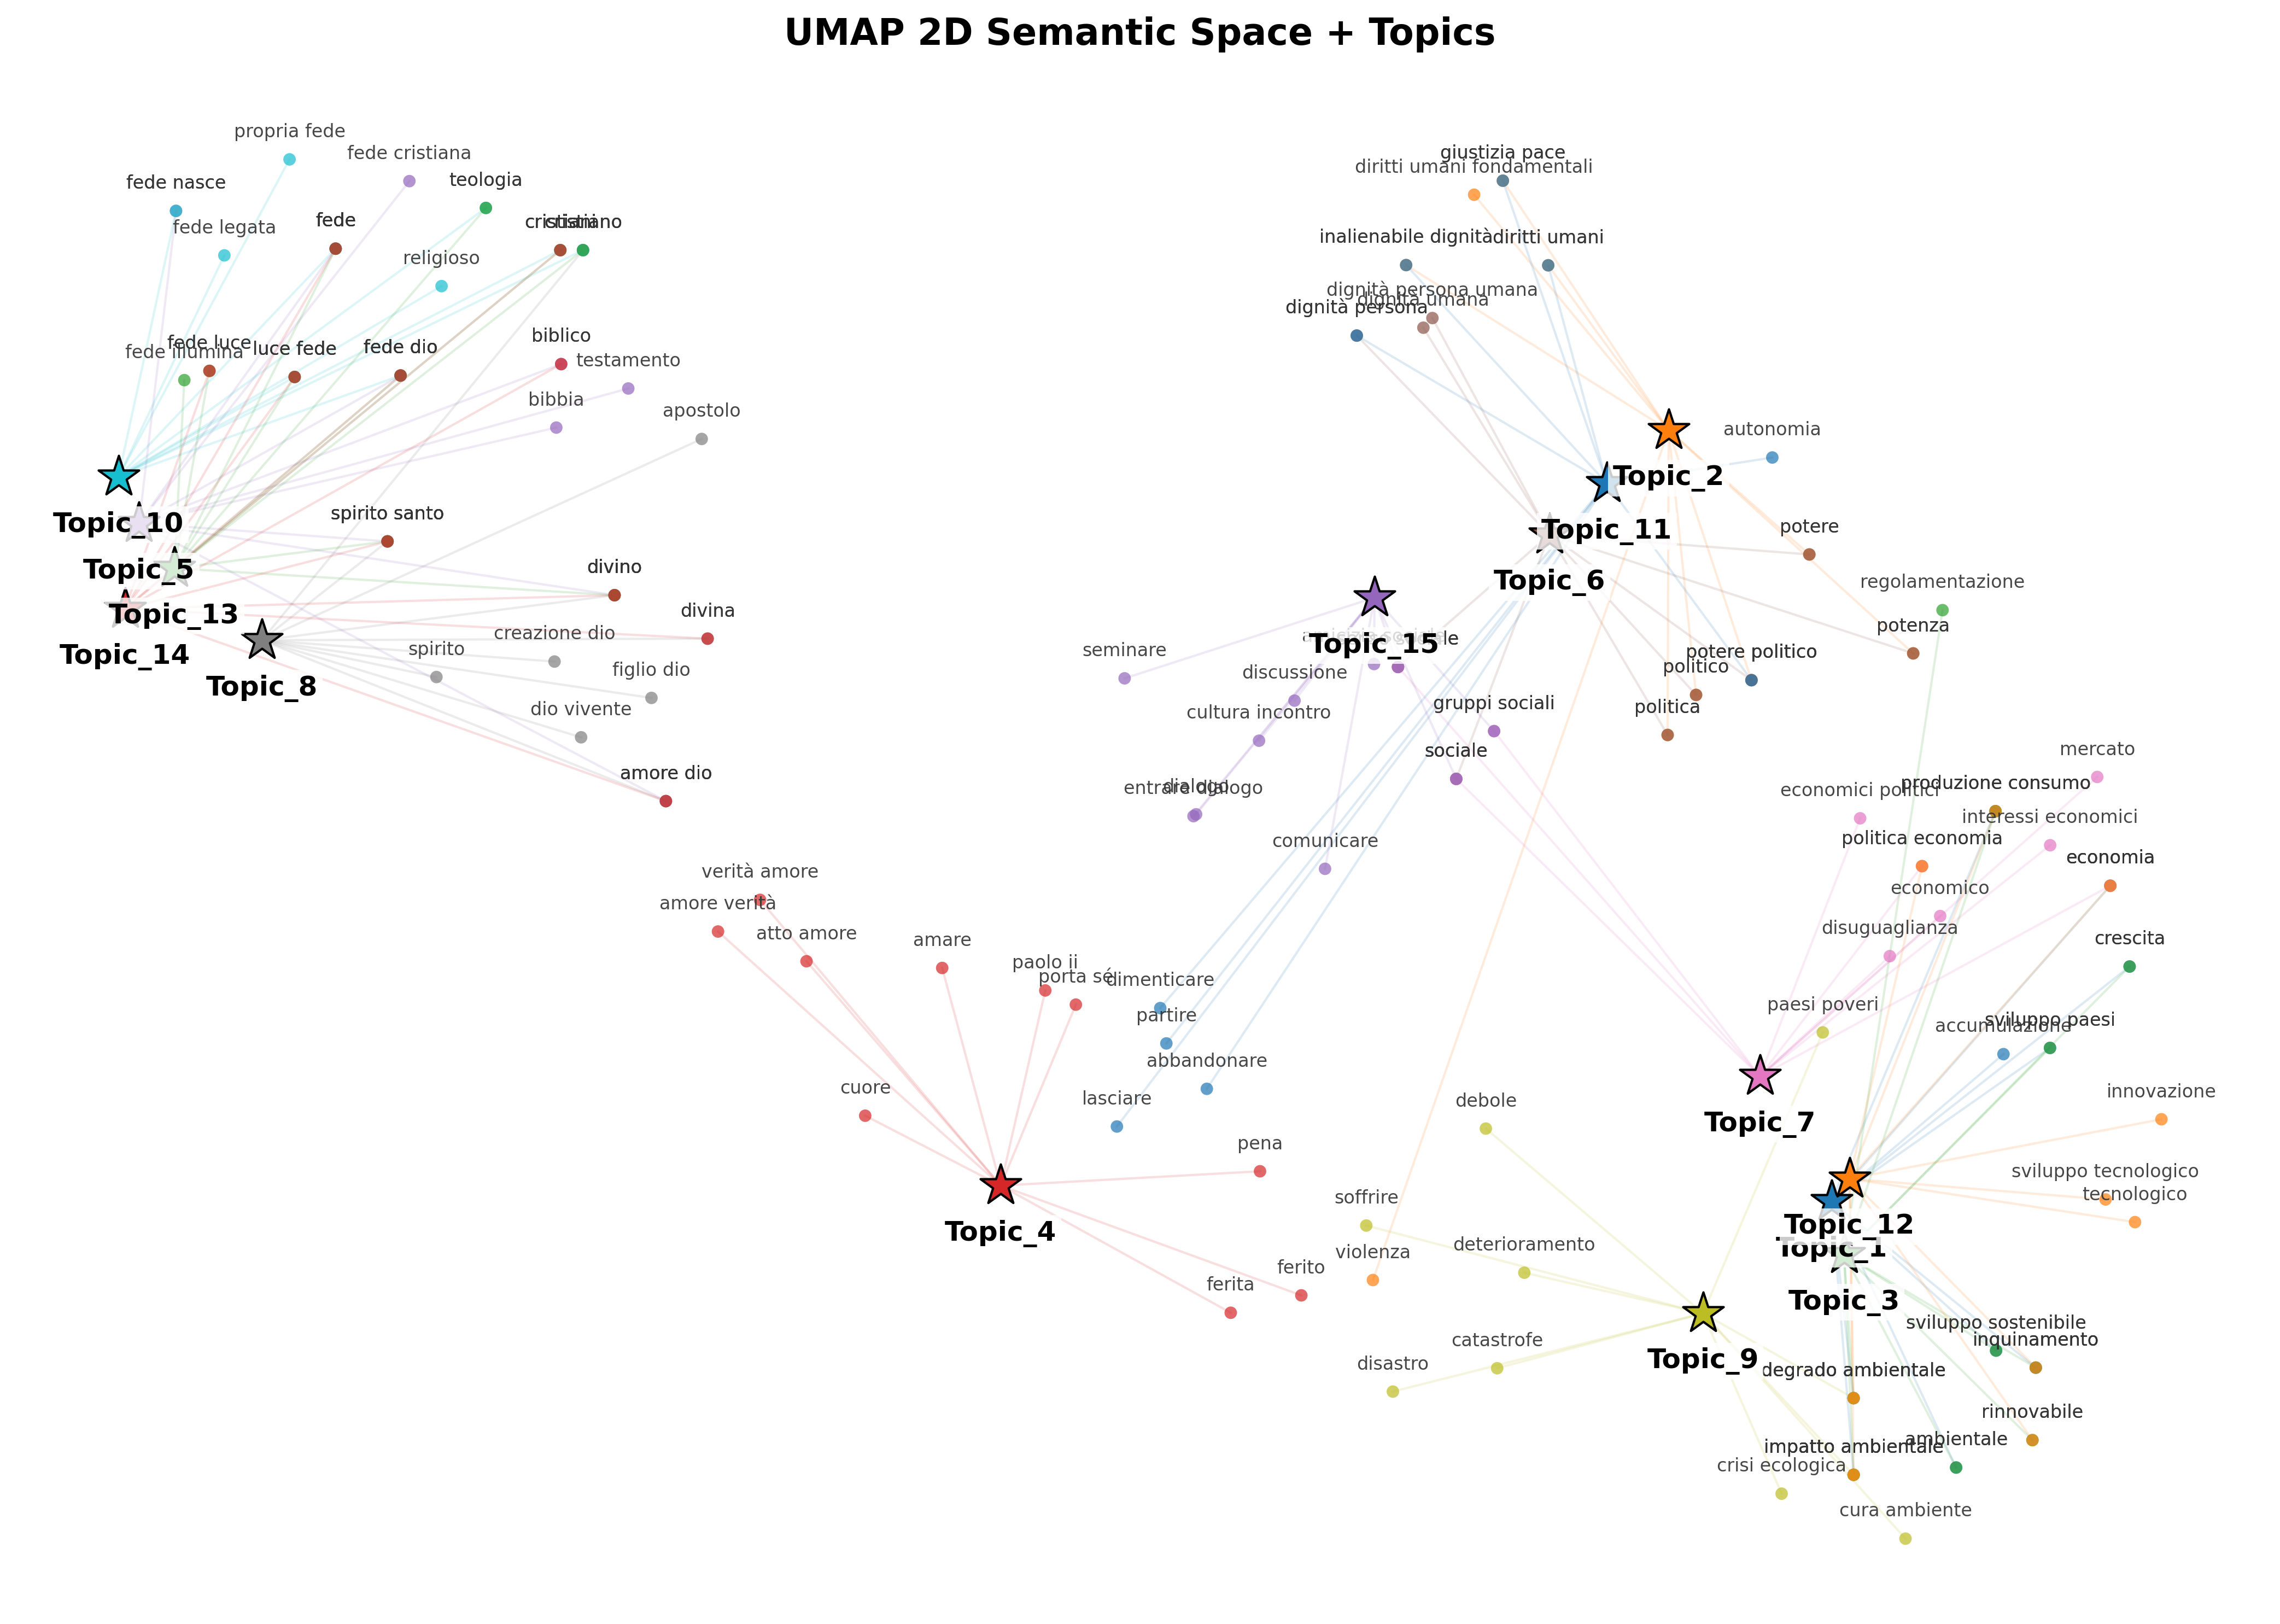

In [17]:
# visualization
model.visualize_2d()

In [18]:
model.visualize_3d()


Extracting single words + MWEs per topic...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


Computing 3D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# vocabolario e embedding già dentro il modello
vocab = model._vocab                                    # lista di lemmi
embs  = model._static_word_embs.detach().cpu().numpy() # (n_vocab, dim)
stop  = set(model._stop)

# rimuovi stopwords
mask     = [i for i, w in enumerate(vocab) if w not in stop and len(w) > 2]
vocab_f  = [vocab[i] for i in mask]
embs_f   = normalize(embs[mask])                       # cosine → L2

# k-means con stesso K
K = 15
km = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = km.fit_predict(embs_f)

# top-10 parole per cluster (per distanza al centroide)
print("=== K-Means sul vocabolario SBERT ===\n")
for k in range(K):
    idx   = np.where(labels == k)[0]
    dists = np.linalg.norm(embs_f[idx] - km.cluster_centers_[k], axis=1)
    top   = [vocab_f[idx[i]] for i in np.argsort(dists)[:10]]
    print(f"Cluster_{k+1:02d}: {', '.join(top)}")

=== K-Means sul vocabolario SBERT ===

Cluster_01: risultare, ugualmente, necessariamente, riguardo, dotare, pertanto, qualsiasi, ormai, capire, gal
Cluster_02: convivenza, congiunto, connesso, comune, collaborare, collettivo, legame, uniscere, condiviso, solidale
Cluster_03: credente, dottrina, religioso, cristo, vescovi, divina, fede, adorazione, cristiani, sacro
Cluster_04: percepire, nozione, vicenda, considerare, contemplare, riflettere, astratto, interpretare, rivelare, apparenza
Cluster_05: gravemente, pena, danneggiare, nocivo, problematica, miseria, soffrire, pericoloso, cattivo, distruttivo
Cluster_06: piacere, tesoro, umile, tenerezza, amare, adorare, accogliere, ammirare, amore, apprezzare
Cluster_07: tecnico, fisico, spazio, accendere, ambiente, prodotto, materia, sintesi, materiale, terreno
Cluster_08: basare, privo, anzi, esortare, risorto, tratto, avvenire, sottile, esigere, legge
Cluster_09: provenire, concezione, pratico, procedere, riguardare, favorire, realizzazione

# SU DATI PAPA

## SU DATI E-A

In [2]:
from scptm import SCPTM, SCPTMConfig
from scptm.evaluation import compute_npmi_coherence, compute_topic_diversity
from scptm.graph import prepare_corpus
import pandas as pd

df = pd.read_csv('/Users/alemeneghini/Dropbox/stat/smackmybitchapp/monitor_data/corpus_reviews.tsv', sep='\t')
df
docs = df['text_raw'].to_list()
docs

['ragazza veramente simpatica e bella con corpo spettacolare e capacità soprannaturali. Abbiamo fatto bj e ne sono veramente soddisfatto. Incontro di 30 minuti, pattuito 2VU. È facilissima da trovare e ti aiuta se non riesci.',
 'ragazza sui 35 anni, foto reali molto simpatica e brava a metterti a tuo agio. Abbiamo concordato 2 VU per 30 mezz’ora con un po di tutto. Riceve in zona talenti facilmente accessibile appartamento pulito e molto carino. incontro pattuito 30 minuti x 2 vu Riceve in una bella zona, facilmente trovabile, riceve da sola veramente una bella ragazza',
 "Ragazza simile ma non corrispondente alle foto. Bel fisico e comunque decido di restare. Ci accordiamo per 3VU per un'ora con bevuta compresa. Se, come me, siete amanti dello squirting rimarrete delusi. Giusto un pò in 69 ma niente di che. Iniziamo con lavaggio di rito e dopo un pò di preliminari la assaggio in 69 e squirta un pochino. Poi fa di tutto per farmi venire con la mano e ci riesce. A mia richiesta di cont

In [7]:
# Lancia SCPTM
model = SCPTM(
    num_topics = 8,
    epochs     = 50,
    graph_mode = "filtered",   # 
    lang= "ita",
    apply_chunking = True,
    max_chunk_chars = 200,
)
model.fit_transform(docs)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3871.96it/s]


NLP pipeline: SBERT='paraphrase-multilingual-MiniLM-L12-v2' on cpu, spaCy='it_core_news_sm' on CPU
Loaded 7157 raw documents.
Final corpus: 22368 segments.

[Graph] Mode: 'filtered' — Informative dependency types only (default)
1/5  Building lemma vocabulary...


Lemmatisation: 100%|██████████| 22368/22368 [02:08<00:00, 173.93it/s]


  Vocabulary: 4030 unique lemmas.
2/5  Encoding documents (SBERT)...


Batches: 100%|██████████| 699/699 [02:29<00:00,  4.68it/s]


...

Batches: 100%|██████████| 126/126 [00:04<00:00, 30.30it/s]


  PMI sparsification: 113,222 → 29,485 word-word edges (74% reduction)
5/5  Building edge tensors...
  Doc-word edges : 260,136
  Word-word edges: 29,485

[Memory estimate]
  node_features_MB         : 38.7
  edge_index_MB            : 2.2
  activations_MB           : 116.0
  gradients_MB             : 77.3
  total_estimated_GB       : 0.23


Contextual embeddings: 100%|██████████| 22368/22368 [08:17<00:00, 44.98it/s]


  Vocabulary coverage: 99.6% (4012/4030 lemmas)
  Topic embeddings initialised from word-embedding k-means (mean top-sim per word: 0.781)
  Trainable word embeddings initialised from SBERT.

Training — mode=filtered, device=cpu
  Mixed precision: True | Neighbor sampling: False
Epoch 010/50  Loss=7.189  Recon=6.774  KL=0.846  KL-w=0.500  NPMI=-0.240  Div=0.912
Epoch 020/50  Loss=7.588  Recon=6.786  KL=0.812  KL-w=1.000  NPMI=-0.229  Div=0.925
Epoch 030/50  Loss=7.583  Recon=6.782  KL=0.812  KL-w=1.000  NPMI=-0.182  Div=0.875
Epoch 040/50  Loss=7.580  Recon=6.779  KL=0.812  KL-w=1.000  NPMI=-0.172  Div=0.887
Epoch 050/50  Loss=7.578  Recon=6.778  KL=0.811  KL-w=1.000  NPMI=-0.171  Div=0.850


tensor([[0.1010, 0.1344, 0.1229,  ..., 0.1536, 0.0948, 0.1194],
        [0.1047, 0.1224, 0.1415,  ..., 0.1584, 0.0970, 0.1064],
        [0.2141, 0.0877, 0.0865,  ..., 0.1034, 0.2296, 0.0890],
        ...,
        [0.1693, 0.1103, 0.1171,  ..., 0.1076, 0.1708, 0.1072],
        [0.1151, 0.1163, 0.1190,  ..., 0.1528, 0.1092, 0.1159],
        [0.0853, 0.1107, 0.1473,  ..., 0.1594, 0.0854, 0.1280]])

In [12]:
# Topic words
model.get_topic_info(top_k=20)

 topic_id  size                                                                                                                                                                                                                 keywords
        2  4322             interruzione, trattenere, ricevuto, incontri, dipendere, fuck, stabilito, congruo, prevedere, elencare, relativo, offerto, scelgere, contattata, giostra, comprese, incorniciare, durata, interrompere, talk
        6  3696                                reale, ambrato, capello, marmoreo, latino, simile, cubano, quarto, tipologia, esattamente, giovane, prosperoso, sudamericano, affusolato, fake, bambolina, tatto, piena, ragazzo, carnoso
        3  3063                               ascoltare, provvedere, migliore, intendere, gran, educata, bisogno, rivelare, esco, ellen, simpatico, volgare, predisposizione, modo, gnocca, sociale, regina, commento, sofia, portamento
        1  2995           industriale, pagamento, easy, difficoltoso

,topic_id,size,keywords
0,2,4322,"interruzione, trattenere, ricevuto, incontri, ..."
1,6,3696,"reale, ambrato, capello, marmoreo, latino, sim..."
2,3,3063,"ascoltare, provvedere, migliore, intendere, gr..."
3,1,2995,"industriale, pagamento, easy, difficoltoso, st..."
4,8,2256,"riempire, intenso, energia, proseguare, pecos,..."
5,4,2222,"sessione, bravura, molto, reciproco, accennare..."
6,7,2088,"interno, fronte, ordine, ambiente, palazzina, ..."
7,5,1726,"reale, capello, simile, ambrato, marmoreo, lat..."


In [15]:
td = model.get_topics_dict(top_k=10)
for name, data in td.items():
    print(f"\n{name}")
    print("  parole:", data["single"][:10])
    print("  MWE:   ", data["phrases"][:10])


Topic_1
  parole: ['garage', 'parking', 'condizionatore', 'appartamento', 'apartment', 'apartamento', 'area', 'condominio', 'alloggio', 'privacy']
  MWE:    ['location pulita riservata', 'appartamento facile parcheggio', 'location riservata zona', 'zona riservata parcheggio', 'location riservata parcheggio', 'appartamento pulito parcheggio', 'appartamento curato riservato', 'appartamento pulito riservato', 'riservata parcheggio comodo', 'appartamento riservato pulito']

Topic_2
  parole: ['minutes', 'minuta', 'time', 'minuto', 'orario', 'minuti', 'momento', 'conversare', 'dialogo', 'pazienza']
  MWE:    ['40 45 minuti', '40 minuti', '45 50 minuti', 'minuti compagnia', '40 minuti incontro', 'incontro 40 minuti', 'quaranta minuti', '20 40 minuti', '40ina minuti', '20 minuti pagato']

Topic_3
  parole: ['cittadino', 'alice', 'perfetta', 'perfetto', 'amanda', 'min', 'ending', 'incontrarla', 'you', 'attitudine']
  MWE:    ['ottimo social donna', 'happy ending', 'social ottimo', 'social ott

In [ ]:
import re, math
from collections import Counter

def top_pmi_bigrams(docs, n=200, min_count=5):
    uni, bi = Counter(), Counter()
    for doc in docs:
        toks = re.findall(r"[a-z]{2,}", doc.lower())
        for w in toks: uni[w] += 1
        for a, b in zip(toks, toks[1:]): bi[(a,b)] += 1
    N1, N2 = sum(uni.values()), sum(bi.values())
    pmi = {f"{a} {b}": math.log(c/N2 / (uni[a]/N1) / (uni[b]/N1))
           for (a,b), c in bi.items() if c >= min_count}
    return set(sorted(pmi, key=pmi.get, reverse=True)[:n])

# MWE da SCPTM (tutte le phrase di tutti i topic)
td = model.get_topics_dict(top_k=10)
scptm_mwes = set()
for data in td.values():
    scptm_mwes.update(data["phrases"])

pmi_bigrams = top_pmi_bigrams(docs, n=200)

only_scptm = scptm_mwes - pmi_bigrams   # grafo sintattico aggiunge qualcosa
only_pmi   = pmi_bigrams - scptm_mwes   # PMI cattura ma SCPTM no
shared     = scptm_mwes & pmi_bigrams   # overlap = pura collocazione frequente

print(f"Solo SCPTM (contributo grafo): {len(only_scptm)}")
print(f"Solo PMI:                      {len(only_pmi)}")
print(f"Overlap:                       {len(shared)}")
print("\nEsempi solo SCPTM:", list(only_scptm)[:10])
print("Esempi overlap:   ", list(shared)[:10])

# Filtra solo le MWE biparola
scptm_bigrams = {m for m in scptm_mwes if len(m.split()) == 2}
overlap_bigrams = scptm_bigrams & pmi_bigrams

print(f"SCPTM bigrams: {len(scptm_bigrams)}")
print(f"Overlap con PMI: {len(overlap_bigrams)}")

Solo SCPTM (contributo grafo): 66
Solo PMI:                      199
Overlap:                       1

Esempi solo SCPTM: ['gran bella donna', 'minuti compagnia', 'continua massaggio', 'appartamento pulito profumato', 'bella ragazza latina', 'ragazza foto bella', '40ina minuti', 'piacere incontrarla', 'bellissima ragazza foto', 'ragazza stupenda foto']
Esempi overlap:    ['happy ending']


In [ ]:
# Filtra solo le MWE biparola
scptm_bigrams = {m for m in scptm_mwes if len(m.split()) == 2}
overlap_bigrams = scptm_bigrams & pmi_bigrams

print(f"SCPTM bigrams: {len(scptm_bigrams)}")
print(f"Overlap con PMI: {len(overlap_bigrams)}")

SCPTM bigrams: 29
Overlap con PMI: 1


In [17]:
from scipy.stats import entropy
theta = model._theta.numpy()
ent = [entropy(theta[i]) for i in range(len(theta))]

In [19]:
import numpy as np

dom = np.argmax(theta, axis=1)
pd.Series(dom).value_counts()

1    4322
5    3696
2    3063
0    2995
7    2256
3    2222
6    2088
4    1726
Name: count, dtype: int64


Extracting single words + MWEs per topic...
Computing 2D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


High-resolution figure saved: semantic_space_2d.png


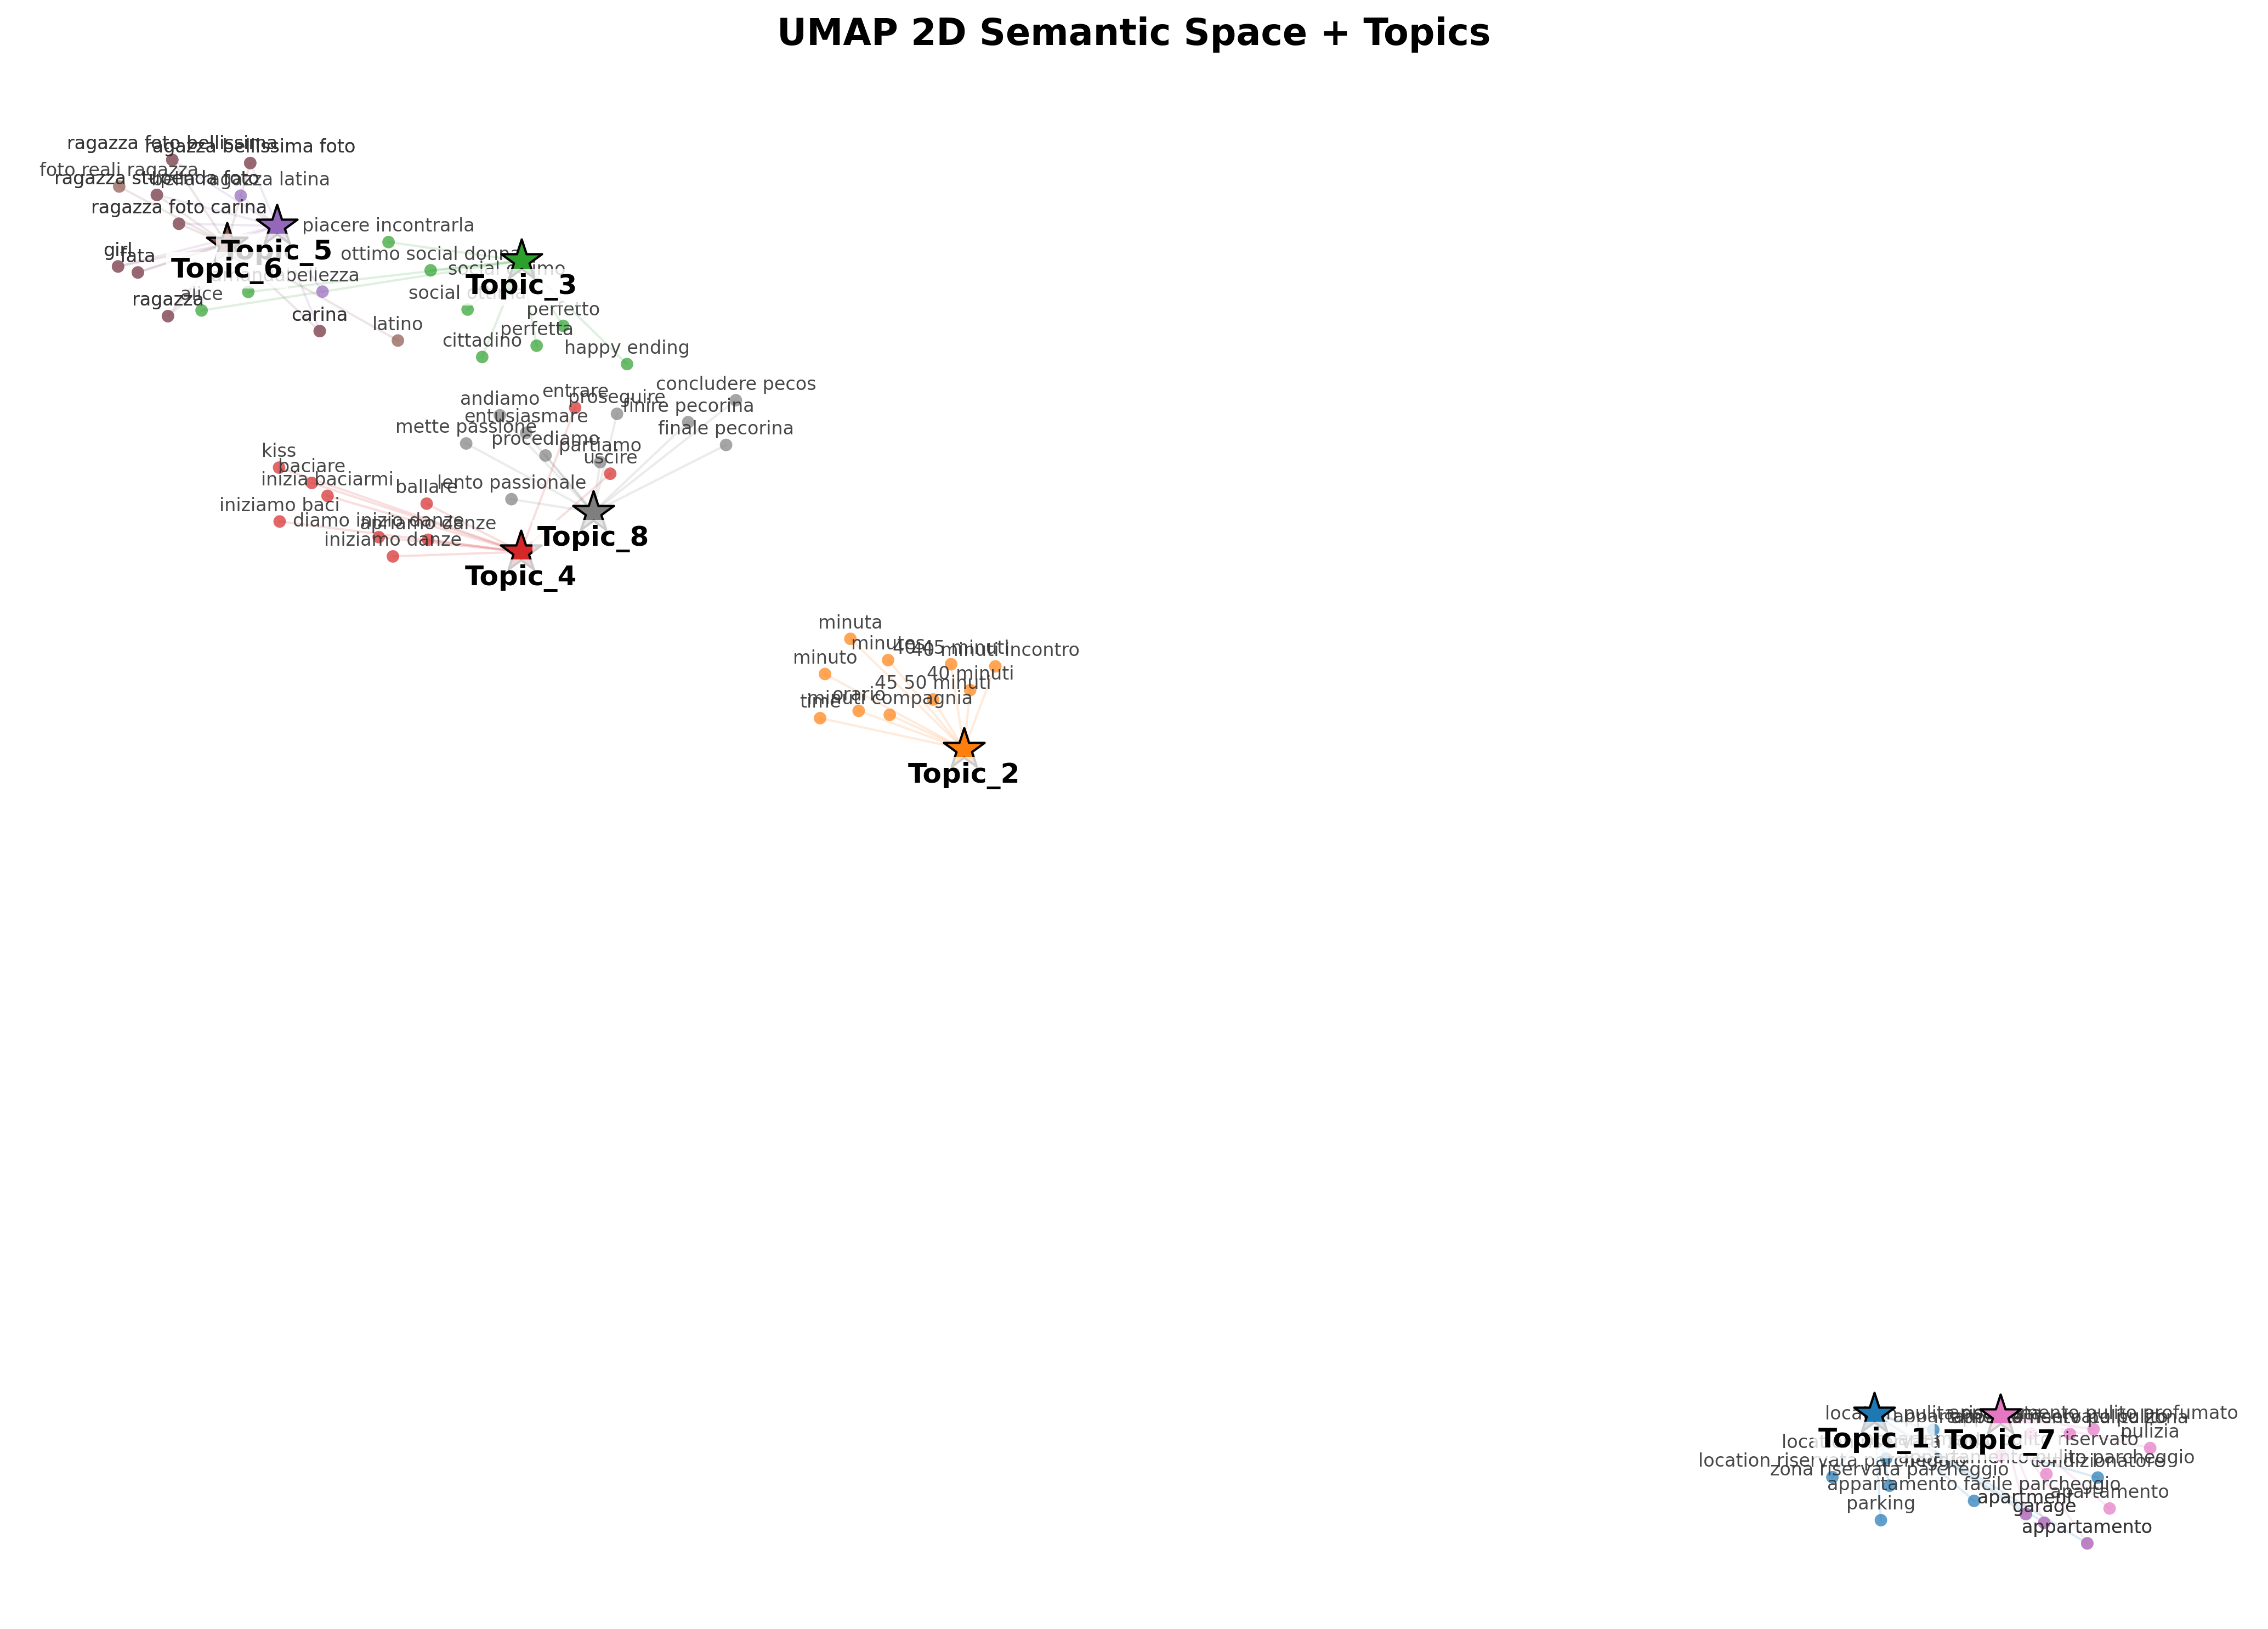

In [14]:
model.visualize_2d()

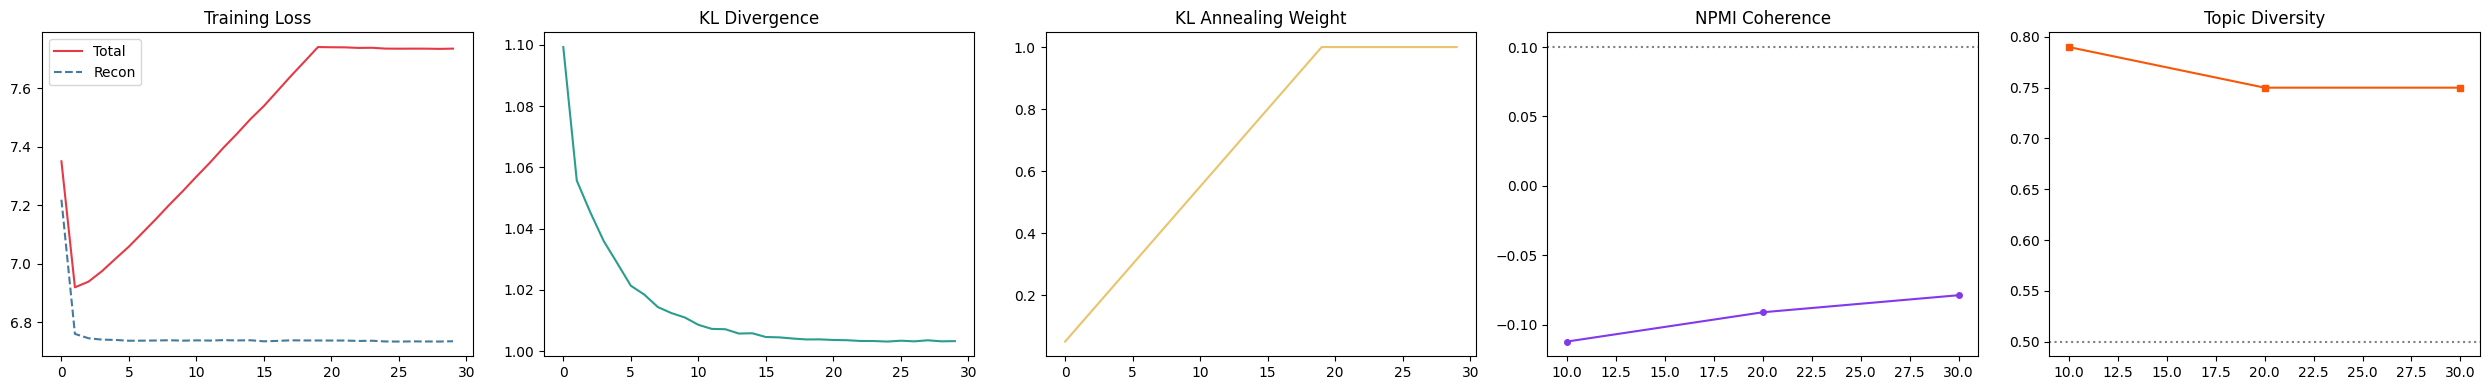

Saved: training_history.png

Extracting single words + MWEs per topic...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


Computing 2D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


High-resolution figure saved: semantic_space_2d.png


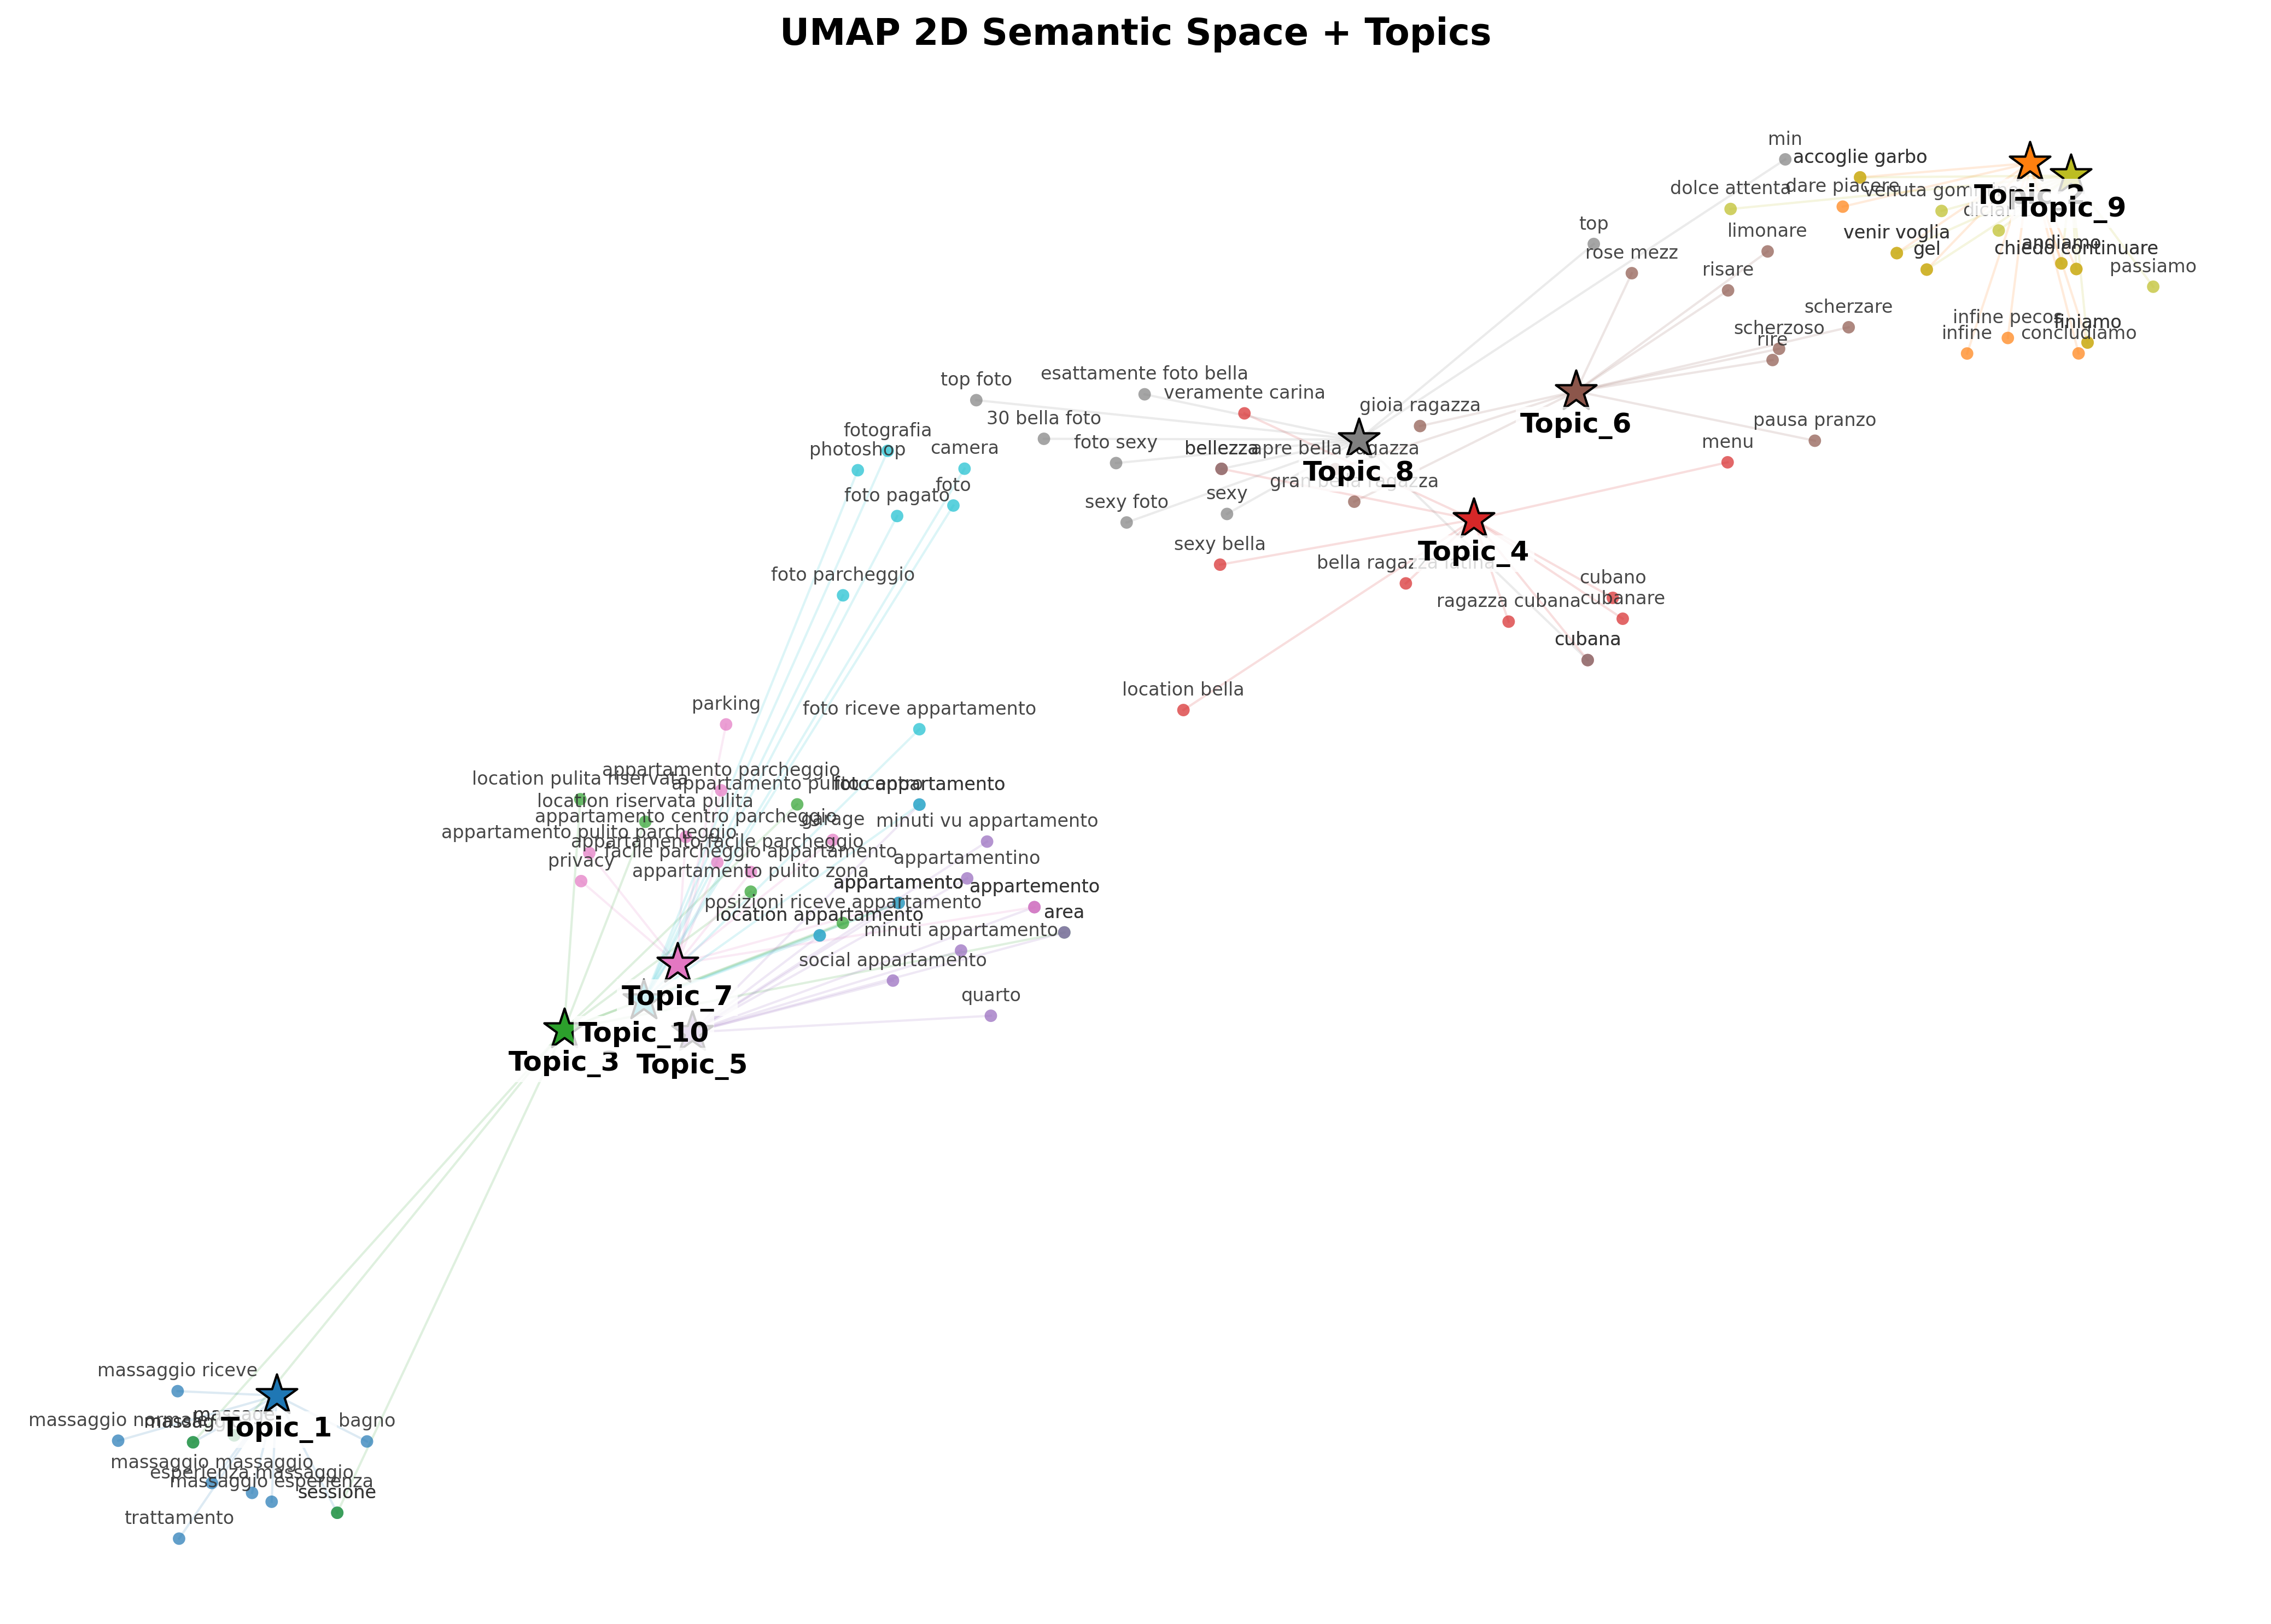


Extracting single words + MWEs per topic...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


Computing 3D UMAP projection...


/Users/alemeneghini/Dropbox/stat/CPTM/260521_SCPTM/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [10]:

# ── Plot 1: curva di training (loss, NPMI, diversity) ──
model.plot_training()

# ── Plot 2: mappa 2D UMAP per pubblicazione (salva PNG) ──
model.visualize_2d()

# ── Plot 3: costellazione semantica 3D interattiva (Plotly) ──
model.visualize_3d()

# SU DATI SODA

In [12]:
from scptm import SCPTM, SCPTMConfig
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from scptm.evaluation import compute_npmi_coherence, compute_topic_diversity
from scptm.graph import prepare_corpus
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

df = pd.read_csv('/Users/alemeneghini/Dropbox/PHD-Padova/SODA/corpora/t1_ita.csv')
docs = df['q1'].to_list()


# Lancia SCPTM
model = SCPTM(
    num_topics = 10,
    epochs     = 20,
    graph_mode = "filtered",   # 
    lang= "ita"
)
model.fit_transform(docs)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8356.44it/s]


NLP pipeline: SBERT='paraphrase-multilingual-MiniLM-L12-v2' on cpu, spaCy='it_core_news_sm' on CPU
Loaded 22470 raw documents.
Final corpus: 17490 segments.

[Graph] Mode: 'filtered' — Informative dependency types only (default)
1/5  Building lemma vocabulary...


Lemmatisation: 100%|██████████| 17490/17490 [01:01<00:00, 283.11it/s]


  Vocabulary: 1819 unique lemmas.
2/5  Encoding documents (SBERT)...


Batches: 100%|██████████| 547/547 [01:13<00:00,  7.42it/s]


...

Batches: 100%|██████████| 57/57 [00:02<00:00, 26.26it/s]


5/5  Building edge tensors...
  Doc-word edges : 157,007
  Word-word edges: 61,780

[Memory estimate]
  node_features_MB         : 28.3
  edge_index_MB            : 1.7
  activations_MB           : 84.9
  gradients_MB             : 56.6
  total_estimated_GB       : 0.17


Contextual embeddings: 100%|██████████| 17490/17490 [05:22<00:00, 54.23it/s]


  Vocabulary coverage: 99.2% (1804/1819 lemmas)
  Topic embeddings initialised from word-embedding k-means (mean top-sim per word: 0.804)

Training — mode=filtered, device=cpu
  Mixed precision: True | Neighbor sampling: False
Epoch 010/20  Loss=7.175  Recon=6.654  KL=1.030  KL-w=0.500  NPMI=-0.240  Div=0.920
Epoch 020/20  Loss=7.673  Recon=6.661  KL=1.006  KL-w=1.000  NPMI=-0.228  Div=0.960


tensor([[0.1042, 0.1028, 0.1377,  ..., 0.0837, 0.1125, 0.0968],
        [0.0752, 0.0959, 0.1505,  ..., 0.0884, 0.0691, 0.0718],
        [0.0790, 0.1126, 0.1542,  ..., 0.0943, 0.1224, 0.0790],
        ...,
        [0.1186, 0.0699, 0.1350,  ..., 0.0955, 0.1275, 0.1029],
        [0.0730, 0.1178, 0.0790,  ..., 0.1118, 0.1087, 0.0740],
        [0.1311, 0.1306, 0.1166,  ..., 0.0670, 0.1198, 0.0673]])

In [13]:
# Topic words
model.get_topic_info(top_k=10)

 topic_id  size                                                                                                                  keywords
        3  3134                                                   ti, ci, chiedi, vuoi, resto, li, neanche, ne, differenziare, innegabile
        4  3107                              sussistere, verificare, inteso, prestare, questione, conoscenza, appunto, chiaro, solo, ambo
        7  2094                 essa, svolgimento, compiere, concordato, determinato, considerere, unanime, azione, svolgere, conseguente
        5  1989                             interpretabile, limpido, ragionevole, parola, si, equivoco, avere, diversamente, frase, segno
        2  1673 spontanea, capace, esplicitare, espressione, chiara, visibilmente, esplicitazione, volere, condizionamenti, dichiarazione
        1  1255               vorresti, condivisione, comunico, delimitare, cosa, linguaggio, gestuale, rientrare, rispecchiare, immagine
        6  1238                   

,topic_id,size,keywords
0,3,3134,"ti, ci, chiedi, vuoi, resto, li, neanche, ne, ..."
1,4,3107,"sussistere, verificare, inteso, prestare, ques..."
2,7,2094,"essa, svolgimento, compiere, concordato, deter..."
3,5,1989,"interpretabile, limpido, ragionevole, parola, ..."
4,2,1673,"spontanea, capace, esplicitare, espressione, c..."
5,1,1255,"vorresti, condivisione, comunico, delimitare, ..."
6,6,1238,"partire, delineare, ritrattabile, collettivo, ..."
7,9,1233,"utilizzare, comunico, personale, consciamente,..."
8,10,927,"sine, qua, volero, disporre, rispondare, voler..."
9,8,840,"yes, consent, concordato, richiesta, accesso, ..."


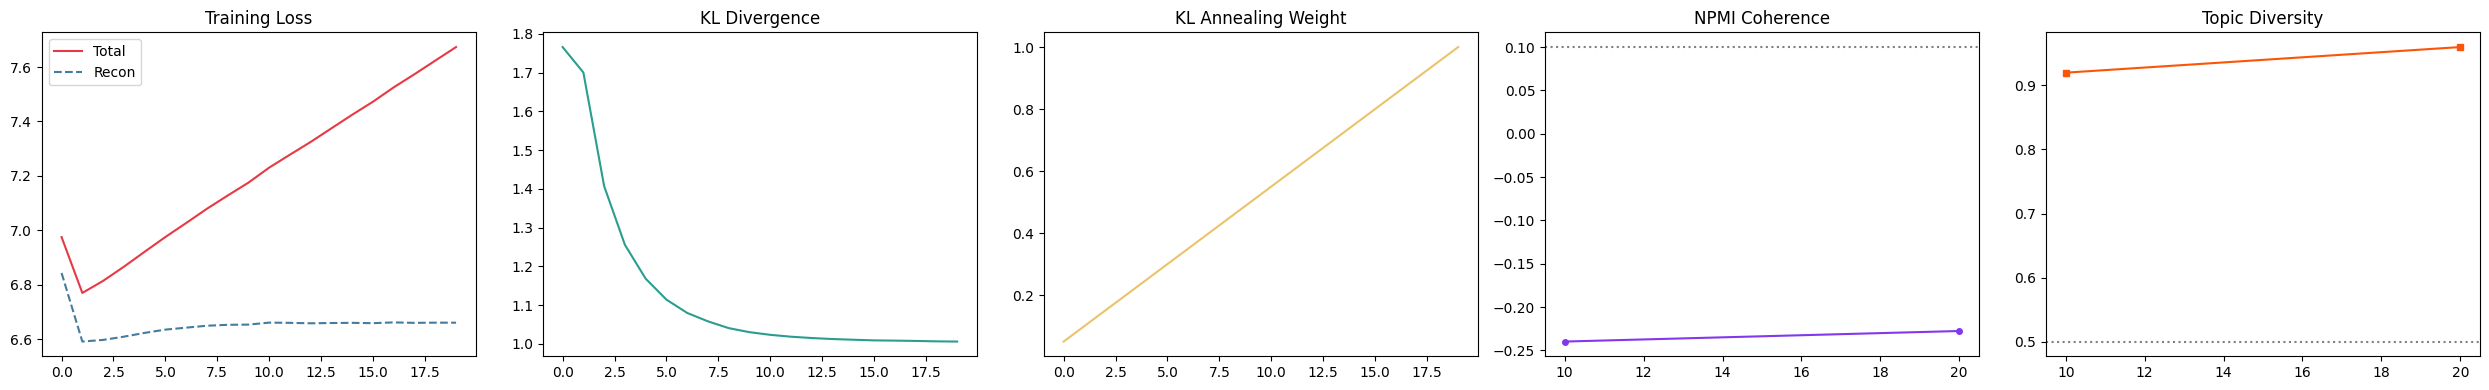

Saved: training_history.png

Extracting single words + MWEs per topic...
Computing 2D UMAP projection...
High-resolution figure saved: semantic_space_2d.png


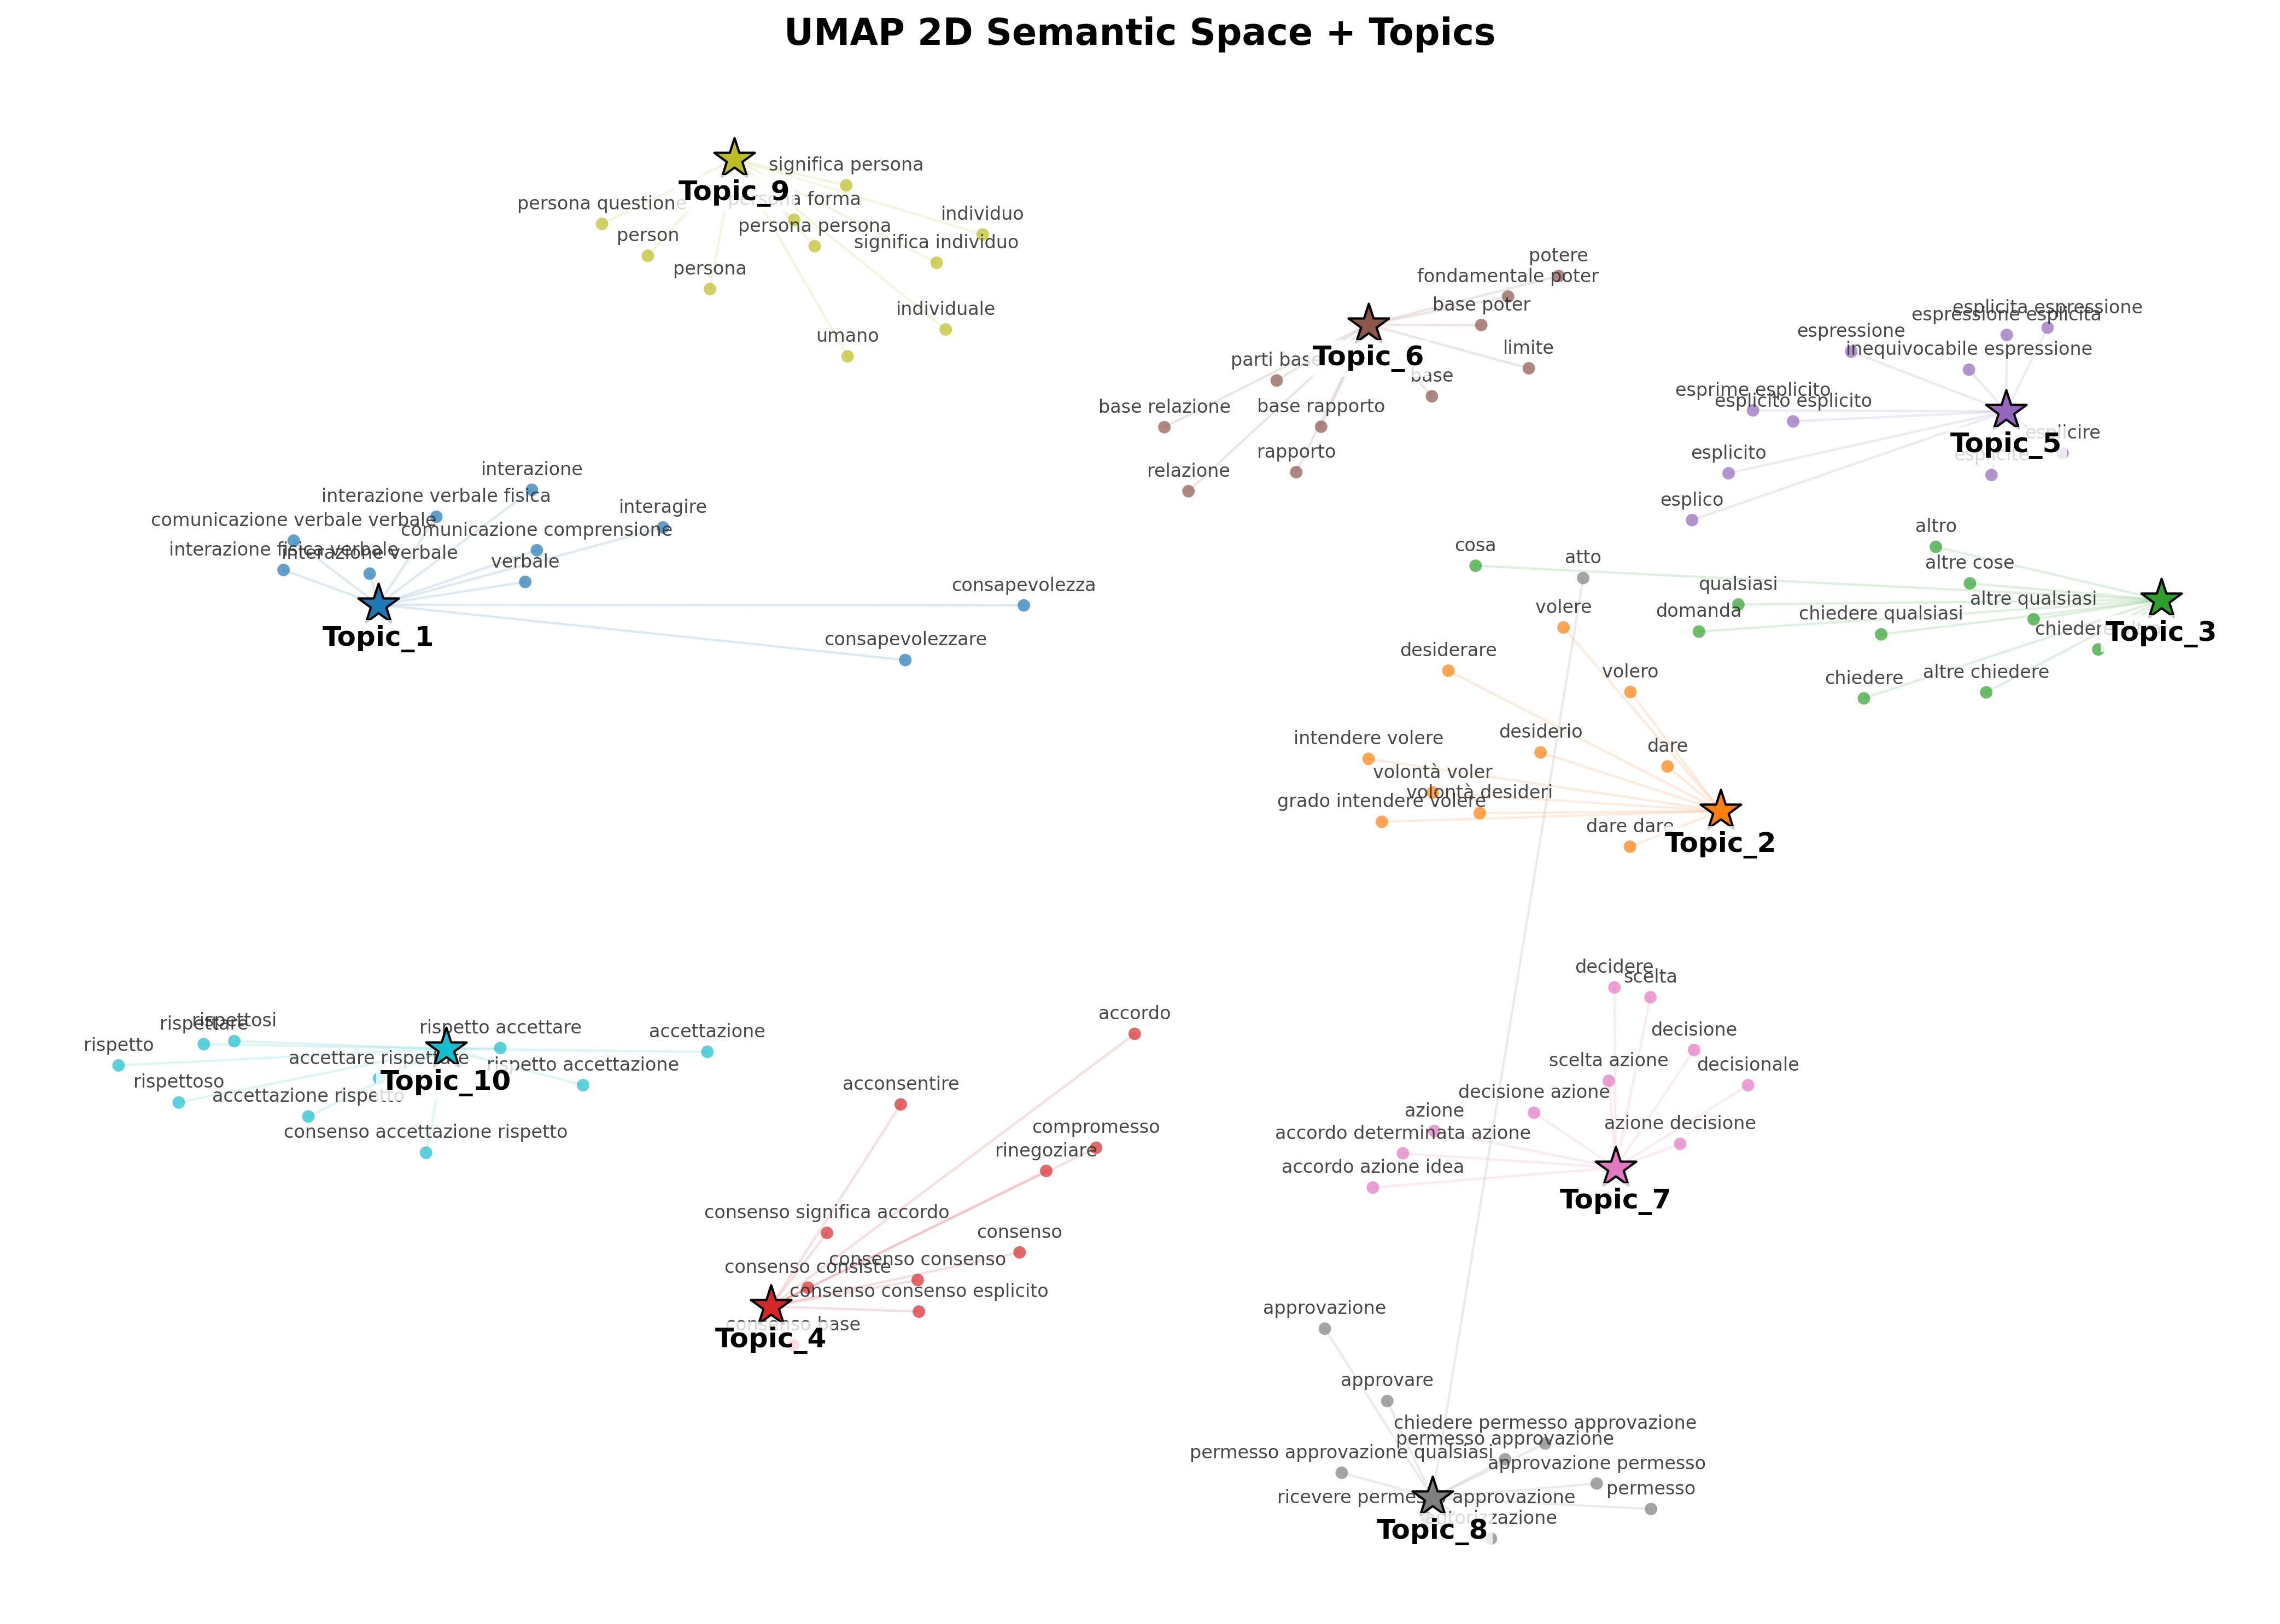


Extracting single words + MWEs per topic...
Computing 3D UMAP projection...


In [14]:

# ── Plot 1: curva di training (loss, NPMI, diversity) ──
model.plot_training()

# ── Plot 2: mappa 2D UMAP per pubblicazione (salva PNG) ──
model.visualize_2d()

# ── Plot 3: costellazione semantica 3D interattiva (Plotly) ──
model.visualize_3d()

In [19]:
import spacy
nlp_ita = spacy.load("it_core_news_sm")
ita_stops = list(nlp_ita.Defaults.stop_words)

# ── LDA ──────────────────────────────────────────────────────────────────────
def lemmatize(doc):
    return [t.lemma_.lower() for t in nlp_ita(doc)
            if not t.is_stop and t.is_alpha and len(t.lemma_) > 2]

tokenised = [lemmatize(d) for d in docs]   # lento ma coerente con SCPTM

dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=5, no_above=0.9)
corpus_bow  = [dictionary.doc2bow(t) for t in tokenised]

lda = LdaMulticore(corpus_bow, num_topics=K, id2word=dictionary,
                   passes=5, workers=2, random_state=42)

# ── BERTopic ─────────────────────────────────────────────────────────────────
vectorizer = CountVectorizer(
    stop_words  = ita_stops,
    min_df      = 3,
    ngram_range = (1, 2),
)

bt = BERTopic(
    embedding_model         = model._sbert,   # riusa da SCPTM
    vectorizer_model        = vectorizer,
    nr_topics               = K,
    calculate_probabilities = True
)
bt_topics, _ = bt.fit_transform(docs, embeddings=embeddings)

In [21]:
# ── LDA topics ───────────────────────────────────────────────────────────────
print("\n── LDA topics ──")
for i in range(K):
    words = [w for w, _ in lda.show_topic(i, topn=10)]
    print(f"Topic {i+1:2d}: {' | '.join(words)}")

# ── BERTopic topics ───────────────────────────────────────────────────────────
print("\n── BERTopic topics ──")
info = bt.get_topic_info()
for _, row in info[info.Topic != -1].head(K).iterrows():
    words = [w for w, _ in bt.get_topic(row.Topic)]
    print(f"Topic {row.Topic+1:2d} (size={row.Count:4d}): {' | '.join(words)}")


── LDA topics ──
Topic  1: persona | altro | consenso | chiedere | qualsiasi | esplicitamente | accettare | azione | permesso | volere
Topic  2: accordo | consenso | parte | chiaro | libero | coinvolto | consapevole | pressione | reciproco | volontario
Topic  3: risposta | esplicito | accettare | richiesta | consenso | chiaro | proposta | domanda | verbale | persona
Topic  4: rispetto | volontà | proprio | reciproco | limite | consenso | rispettare | comunicazione | esprimere | desidere
Topic  5: consenso | volontà | spazio | limite | idea | atto | piacere | personale | possibilità | condizione
Topic  6: libertà | consenso | rispettare | scelta | rispetto | libero | potere | scegliere | decidere | volere
Topic  7: consenso | dare | permesso | potere | persona | significare | venire | esplicito | dovere | scontare
Topic  8: volere | consenso | accettazione | azione | determinato | situazione | intento | accordo | accettare | consapevolezza
Topic  9: approvazione | esplicito | chiaro | 